In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module
import itertools

In [2]:
np.random.seed(3)  # reproducible connectivity + external events

# --- network size ---
N_PYR, N_PV, N_SST = 1000, 100, 100
N = N_PYR + N_PV + N_SST

ntwk = {
    # cell numbers
    'N_PYR': 1000,
    'N_PV': 100,
    'N_SST': 100,
    # connectivity probabilities
    # - from PYR
    'p_PYR_PYR' : 0.1,
    'p_PYR_PV' : 0.1,
    'p_PYR_SST' : 0.1,
    # - from PV
    'p_PV_PYR' : 0.15,
    'p_PV_PV' : 0.1,
    'p_PV_SST' : 0.1,
    # - from SST
    'p_SST_PYR' : 0.2,
    'p_SST_PV' : 0.1,
    'p_SST_SST' : 0.1,
}

# --- random recurrent connectivity matrix, 30% pairwise probability, no autapses ---
# indices of each population
N = ntwk['N_PYR'] + ntwk['N_PV'] + ntwk['N_SST']
ntwk['PYR'] = np.arange(ntwk['N_PYR'])
ntwk['PV'] = np.arange(ntwk['N_PYR'], ntwk['N_PYR']+ntwk['N_PV'])
ntwk['SST'] = np.arange(ntwk['N_PYR']+ntwk['N_PV'], ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST'])

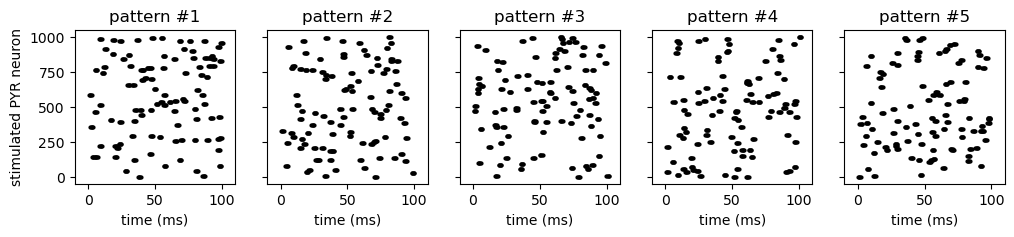

In [10]:
# stimulus
def build_pattern(n_targets=100, 
                  window=100,
                  quantal_per_event=5,
                  seed=0):
    """ we force the pattern to always target the first neuron so that we can easily see evoked activity"""
    np.random.seed(seed+20)
    target_nrns = [0]+list(np.random.choice(np.arange(ntwk['N_PYR']), n_targets-1))
    stim_times = np.random.uniform(0, window, n_targets)
    return np.concatenate([t+np.arange(quantal_per_event)*0.5 for t in stim_times]),\
            np.concatenate([n*np.ones(quantal_per_event, dtype=int) for n in target_nrns], dtype=int)

def enforce_min_isi(times, dt):
    """Snap spike times to the simulation grid and enforce a minimum
    spacing of one dt between consecutive spikes (per neuron)."""
    times = np.sort(np.round(np.asarray(times) / dt) * dt)
    for k in range(1, len(times)):
        if times[k] <= times[k - 1]:
            times[k] = times[k - 1] + dt
    return times

fig, AX = plt.subplots(1,5, figsize=(12,2.))
for ii in range(5):
    AX[ii].plot(*build_pattern(seed=ii), 'ko', ms=2)
    AX[ii].set_ylim([-50, ntwk['N_PYR']+50])
    AX[ii].set_xlim([-10, 110])
    AX[ii].set_xlabel('time (ms)')
    AX[ii].set_ylabel('stimulated PYR neuron' if ii==0 else '')
    AX[ii].set_title('pattern #%i' % (ii+1))
    if ii!=0:
        AX[ii].set_yticklabels([])

In [30]:
from scipy.ndimage import gaussian_filter1d

def run_sim(pattern_id=0,
            quantal_per_event=5,
            n_targets=50, 
            prestim = 100,
            interstim = 100,
            window=50,
            nstim = 10,
            f_ext=0.1,
            seed=3):
    
    brian.start_scope()

    tstop = prestim+nstim*(interstim+window)
    tstims, istims = build_pattern(seed=pattern_id, 
                                   window=window,
                                   n_targets=n_targets,
                                   quantal_per_event=quantal_per_event)

    # connectivity matrix
    np.random.seed(seed)
    conn = np.zeros((N, N))
    for pre, post in itertools.product(['PYR', 'PV', 'SST'],
                                    ['PYR', 'PV', 'SST']):
        conn[np.ix_(ntwk[pre],ntwk[post])] = \
            np.random.rand(len(ntwk[pre]), len(ntwk[post])) < ntwk['p_%s_%s' % (pre, post)]
    np.fill_diagonal(conn, False)
    pre_idx, post_idx = np.nonzero(conn)

    eqs = '''
    dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
    dg_e/dt   = -g_e   / tau_e : siemens
    dg_i/dt   = -g_i   / tau_i : siemens
    dg_ext/dt = -g_ext / tau_e : siemens
    '''

    pop = brian.NeuronGroup(N, eqs, threshold='v>Vt', reset='v=Vr',
                            refractory=Tr,
                            method='exponential_euler')
    pop.v = El

    is_exc_source = pre_idx < ntwk['N_PYR']
    syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
    syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
    syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
    syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

    # --- independent external excitatory events, 3-4 per neuron ---
    ext_factors = np.zeros(N)
    ext_factors[ntwk['PYR']] = 1.5      # for pyramidal neurons
    ext_factors[~ntwk['PYR']] = 0.9    # for interneurons

    ext_times =[
        np.cumsum(np.random.exponential(1./f_ext, int(f_ext*tstop))+1e-1) for n in range(N)
    ]
    for ns in range(nstim):
        for ii in np.unique(istims):
            ext_times[ii] = np.concatenate([ext_times[ii], 
                            prestim+ns*(window+interstim)+tstims[ii==istims]])
    ext_times = [enforce_min_isi(e, 0.5) for e in ext_times]
    #"""
    ext_input = brian.SpikeGeneratorGroup(N, 
        np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                        np.concatenate(ext_times)*ms)

    syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
    syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

    mon = brian.StateMonitor(pop, 'v',
                                record=np.concatenate([np.arange(4),
                                                    ntwk['N_PYR']+np.arange(1),
                                                    ntwk['N_PV']+ntwk['N_PYR']+np.arange(1)]))
    spikes = brian.SpikeMonitor(pop)
    ratePYR = brian.PopulationRateMonitor(pop[ntwk['PYR']])

    brian.run(tstop*ms)

    # from this we calculate the spiking response
    dt = 1
    t = np.arange(-int(interstim/2./dt), int((window+interstim/2.)/dt))*dt
    response = np.zeros((nstim, ntwk['N_PYR'], len(t)))
    t_rate, rates = np.linspace(-interstim/2., window+interstim/2.), []
    for n in range(nstim):
        # pattern
        cond = (spikes.t/ms>(prestim-interstim/2.+n*(interstim+window))) &\
            (spikes.t/ms<(prestim+interstim/2.+n*(interstim+window)+window)) &\
            (spikes.i<ntwk['N_PYR'])
        for ii, tt in zip(spikes.i[cond], spikes.t[cond]/ms):
            new_i = int((tt-(prestim-interstim/2.+n*(interstim+window)))/dt)
            response[n, ii, new_i] += 1
        # rate
        cond = ratePYR.t/ms>prestim-interstim/2.+n*(interstim+window)
        rates.append(ratePYR.smooth_rate(window='gaussian', width=2*ms)[cond][:len(t_rate)]/brian.Hz)
    stim_response = dict(
        t=np.arange(-int(interstim/2./dt), (window+interstim)/dt)*dt,
        prestim=prestim, interstim=interstim, window=window,
        dt=dt,
        nstim = nstim,
        seed=seed,
        t_rate=t_rate, rates=np.array(rates),
        response=gaussian_filter1d(response, 5))
    
    return spikes, mon, ratePYR, stim_response
    #"""
    #return ext_times
    
spikes, mon, ratePYR, stim = run_sim()
#ext_times = run_sim()

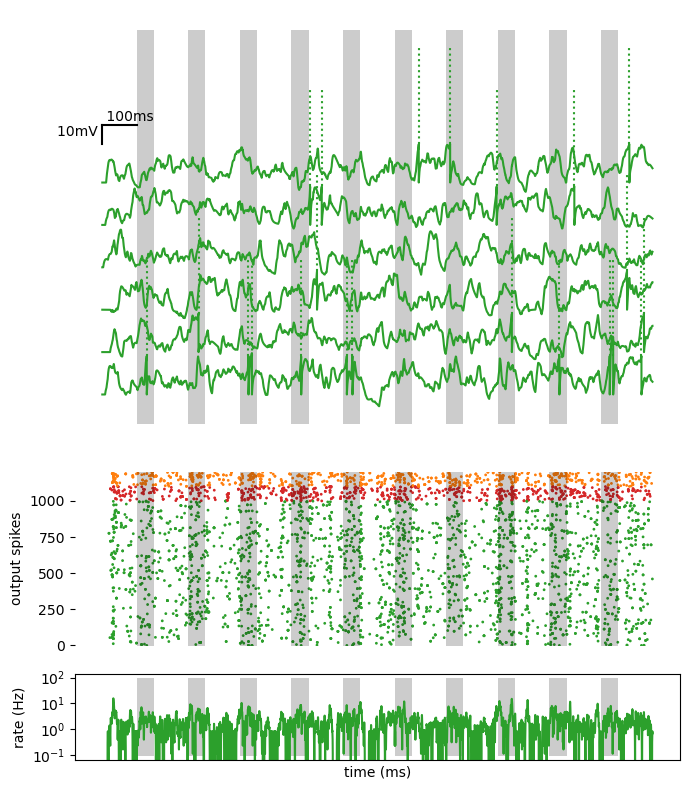

In [31]:
from plots import plot_with_spikes

def plot(mon, spikes, rates, stim):

    # --- plot: connectivity matrix, voltage traces, raster ---
    fig = plt.figure(figsize=(7, 8))
    gs = fig.add_gridspec(3, 1,
                          height_ratios=[5, 2, 1])

    ax_v = fig.add_subplot(gs[0], frameon=False)
    colors = ['C2' for i in range(6)]+['C3', 'C3']+['C1', 'C1']
    for n in range(mon.v.shape[0]):
        plot_with_spikes(ax_v, mon, n, shift=n*22,
                         color=colors[n])

    # show bar scale
    ax_v.plot([0,0], El/mV+(n+2)*20-np.arange(2)*10, 'k-')
    ax_v.plot([0,100], El/mV+(n+2)*20-np.zeros(2), 'k-')
    ax_v.annotate('10mV ', (0,El/mV+(n+2)*20), va='top', ha='right', xycoords='data')
    ax_v.annotate(' 100ms', (0,El/mV+(n+2)*20+2), xycoords='data')
    ax_v.axis('off')

    ax_r = fig.add_subplot(gs[1], sharex=ax_v, frameon=False)
    # we randomly subsample spikes if they are too numerous for display
    spike_subsampling = np.random.choice(np.arange(len(spikes.i)),
                                         np.min([10000, len(spikes.i)]))
    def colors(n):
        if n<ntwk['N_PYR']:
            return 'C2'
        elif n>=ntwk['N_PYR']+ntwk['N_PV']:
            return 'C1'
        else:
            return 'C3'
    ax_r.scatter(spikes.t[spike_subsampling]/ms, spikes.i[spike_subsampling],
                 c=[colors(i) for i in spikes.i[spike_subsampling]], s=1)
    ax_r.set_ylabel('output spikes')
    ax_r.set_xticks([])
    ax_r.set_ylim([-1,N])

    ax_f = fig.add_subplot(gs[2], sharex=ax_v)
    width = 0.5*ms
    for i, rate, color in zip(range(3), rates, ['C2', 'C3', 'C1']):
        ax_f.plot(rate.t/ms, rate.smooth_rate(window='gaussian', width=width)/brian.Hz,
                    color=color)
    ax_f.set_xlabel('time (ms)'); 
    ax_f.set_ylabel('rate (Hz)')
    ax_f.set_yscale('log') 
    ax_f.set_yticks([0.1,1,10,100]) 

    for ax in [ax_v, ax_r, ax_f]:
        ylim = ax.get_ylim()
        for n in range(stim['nstim']):
            ax.fill_between(stim['prestim']+n*(stim['interstim']+stim['window'])+np.arange(2)*stim['window'],
                            ylim[0]*np.ones(2), ylim[1]*np.ones(2), color='k', alpha=.2, lw=0)

    plt.tight_layout()

plot(mon, spikes, [ratePYR], stim)

Text(0.5, 0, 'time from stim. (ms)')

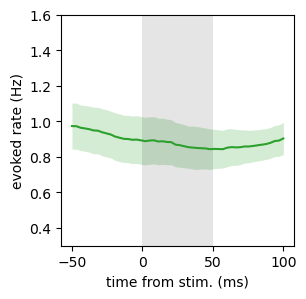

In [43]:
# evoked response
fig, ax = plt.subplots(figsize=(3,3))
ax.plot(stim['t_rate'], stim['rates'].mean(axis=0), color='C2')
ax.fill_between(stim['t_rate'], 
                stim['rates'].mean(axis=0)+sem(stim['rates'],axis=0),
                stim['rates'].mean(axis=0)-sem(stim['rates'],axis=0),
                alpha=.2, lw=0, color='C2')
ax.set_ylim([0.3, 1.6])
ylim=ax.get_ylim()
ax.fill_between([0, stim['window']], ylim[0]*np.ones(2), ylim[1]*np.ones(2), color='k', alpha=.1, lw=0)
ax.set_ylabel('evoked rate (Hz)')
ax.set_xlabel('time from stim. (ms)')


In [6]:
X, y = [], []
for pattern in range(5):
    spikes, mon, ratePYR, stim = run_sim(pattern_id=pattern, seed=pattern+10)
    for repeat in range(stim['response'].shape[0]):
        X.append(stim['response'][repeat,:,:].flatten())
        y.append(pattern)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.5)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [22]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
chance = 1./len(np.unique(y))
print(score)

0.76


Fold scores: [0.6  0.72]
Mean +/- SEM: 0.660 +/- 0.060


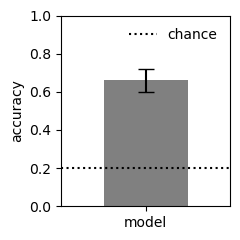

In [23]:
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import sem

cv = KFold(n_splits=2, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

mean_score = scores.mean()
sem_score  = sem(scores)

print(f'Fold scores: {scores}')
print(f'Mean +/- SEM: {mean_score:.3f} +/- {sem_score:.3f}')

# --- bar plot ---
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.bar(['model'], [mean_score], yerr=[sem_score], capsize=6,
       color='gray', width=0.5)
ax.plot([-0.5,.5], [chance, chance], 'k:', label='chance')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.set_xlim([-.5, .5])
ax.legend(frameon=False)
plt.tight_layout()